<a href="https://www.kaggle.com/code/vincentvandeghinste/mtat26-transformers?scriptVersionId=301171361" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 6.2.11 Hands-on Transformers

First we need to download and install the necessary modules.

In [1]:
!wget https://www.ccl.kuleuven.be/~vincent/MTAT/plot_train_val_new.py
!wget http://ccl.kuleuven.be/~vincent/MTAT/transformer.py
from IPython.display import Image, display
!pip -q install -U evaluate sacrebleu

--2026-03-03 10:45:01--  https://www.ccl.kuleuven.be/~vincent/MTAT/plot_train_val_new.py
Resolving www.ccl.kuleuven.be (www.ccl.kuleuven.be)... 134.58.16.193
Connecting to www.ccl.kuleuven.be (www.ccl.kuleuven.be)|134.58.16.193|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8180 (8.0K)
Saving to: ‘plot_train_val_new.py’

plot_train_val_new. 100%[===================>]   7.99K  --.-KB/s    in 0s      

2026-03-03 10:45:01 (107 MB/s) - ‘plot_train_val_new.py’ saved [8180/8180]

--2026-03-03 10:45:01--  http://ccl.kuleuven.be/~vincent/MTAT/transformer.py
Resolving ccl.kuleuven.be (ccl.kuleuven.be)... 134.58.16.193
Connecting to ccl.kuleuven.be (ccl.kuleuven.be)|134.58.16.193|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16755 (16K)
Saving to: ‘transformer.py’

transformer.py      100%[===================>]  16.36K  --.-KB/s    in 0.1s    

2026-03-03 10:45:02 (138 KB/s) - ‘transformer.py’ saved [16755/16755]

   ━━━━━━━━━━━━━━━━━━━━━━━━

Then we run the transformer.py script. The command-line options are shown in the table below.

| Option                | Default | Description                                                   |
| --------------------- | ------- | ------------------------------------------------------------- |
| `--src-file`          | –       | Source language training file (one sentence per line)         |
| `--tgt-file`          | –       | Target language training file (one sentence per line)         |
| `--src-val`           | –       | Source language validation file                               |
| `--tgt-val`           | –       | Target language validation file                               |
| `--spm-src-model`     | –       | SentencePiece model for the source language                   |
| `--spm-tgt-model`     | –       | SentencePiece model for the target language                   |
| `--save`              | `model` | Output directory where the model and tokenizers are saved     |
| `--enc-layers`        | `6`     | Number of Transformer encoder layers                          |
| `--dec-layers`        | `6`     | Number of Transformer decoder layers                          |
| `--emb-size`          | `512`   | Embedding size (model dimension)                              |
| `--hidden-size`       | `2048`  | Feed-forward layer size inside Transformer blocks             |
| `--num-heads`         | `8`     | Number of attention heads                                     |
| `--batch-size`        | `32`    | Number of sentence pairs per training batch                   |
| `--epochs`            | `30`    | Number of training epochs                                     |
| `--lr`                | `5e-4`  | Learning rate for Adam optimizer                              |
| `--max-src-len`       | `128`   | Maximum source sentence length (after subwording)             |
| `--max-tgt-len`       | `128`   | Maximum target sentence length (after subwording)             |
| `--lower`             | `False` | Lowercase input text before tokenization                      |
| `--seed`              | `42`    | Random seed for reproducibility                               |
| `--eval-metrics`      | `False` | Compute automatic metrics (e.g. SacreBLEU) on validation data |
| `--show-val-examples` | `0`     | Number of validation translations to print after each epoch   |
| `--num-beams`         | `4`     | Beam size used for validation-time generation                 |
| `--max-gen-len`       | `128`   | Maximum length of generated translations                      |
| `--history-json`      | `None`  | Path to JSON file for saving training/validation history      |


In [2]:
!python transformer.py \
  --src-file /kaggle/input/tatoeba-en-nl/train.en \
  --tgt-file /kaggle/input/tatoeba-en-nl/train.nl \
  --src-val  /kaggle/input/tatoeba-en-nl/dev.en \
  --tgt-val  /kaggle/input/tatoeba-en-nl/dev.nl \
  --spm-src-model /kaggle/input/transformers-input-spms/spm.en.model \
  --spm-tgt-model /kaggle/input/transformers-input-spms/spm.nl.model \
  --save transformer_run \
  --epochs 10 \
  --eval-metrics \
  --show-val-examples 5 \
  --history-json transformer.hist


E0000 00:00:1772534729.066917      53 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772534729.132947      53 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772534729.689245      53 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772534729.689323      53 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772534729.689332      53 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772534729.689338      53 computation_placer.cc:177] computation placer already registered. Please check linka

Transformers are evaluated every fixed number of training steps rather than only at the end of an
epoch, so we already see validation loss part-way through the epoch.

## Show evaluations

We show the results of training the transformer for 10 epochs on the Tatoeba data set for English
to Dutch in in the figures below.
We see that it takes several epochs before the training
loss gets better than the loss on validation set. We see that we reach Bleu scores
of nearly 50, which is substantially higher than what we saw in the previous section, before using
Transformers.

Saved plot to tf_train_val.png


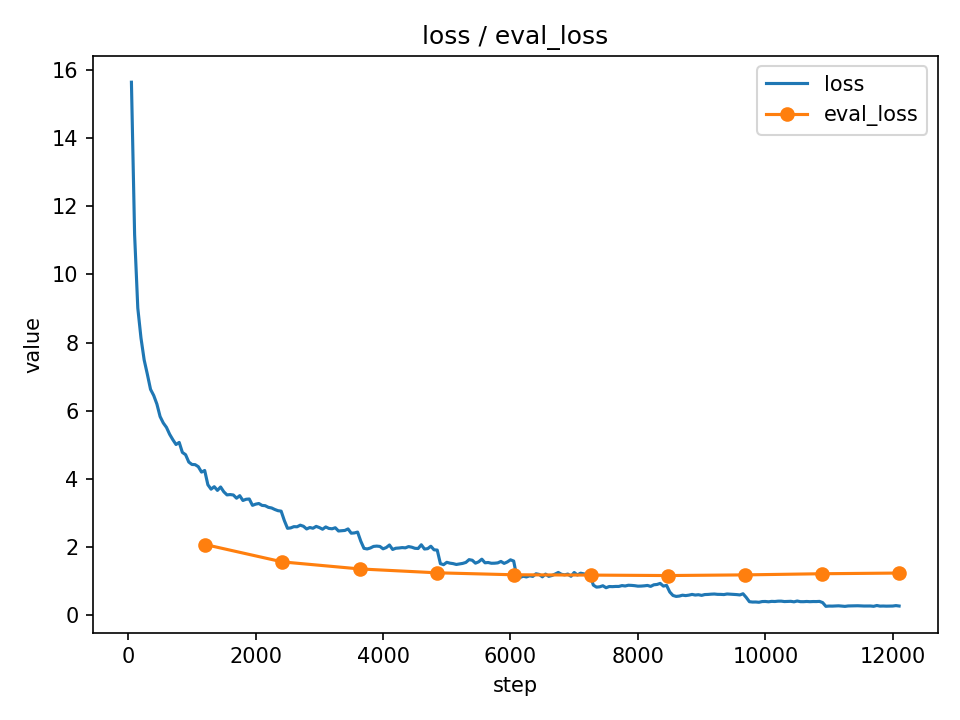

In [3]:
!python plot_train_val_new.py transformer.hist --train-key loss --val-key eval_loss --save tf_train_val.png

display(Image(filename="tf_train_val.png"))

Saved plot to tf_bleu.png


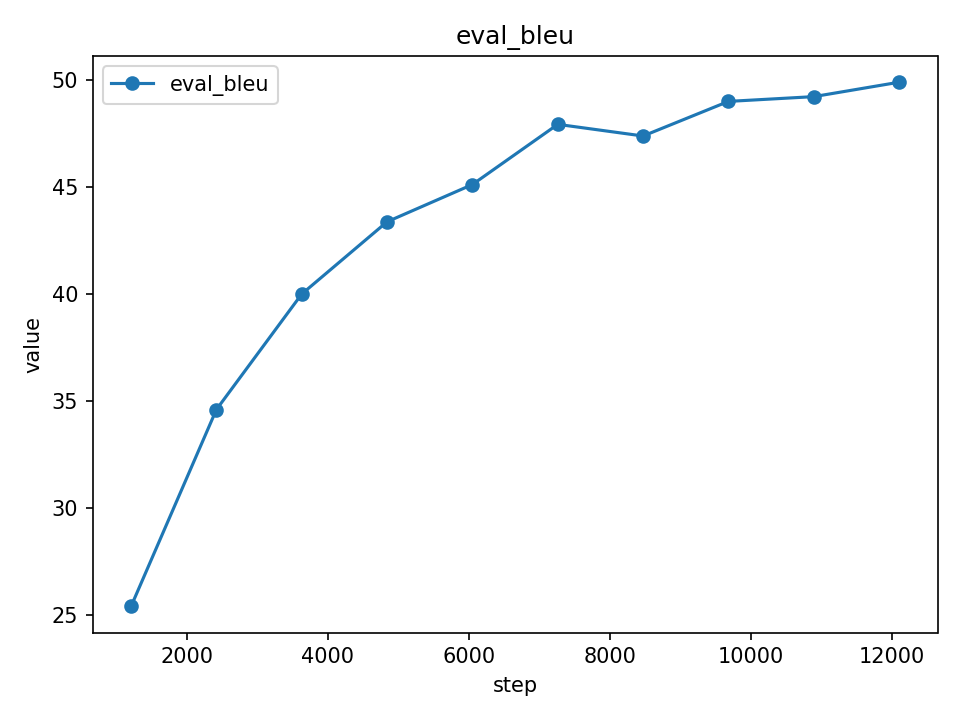

In [4]:
!python plot_train_val_new.py transformer.hist \
  --val-key eval_bleu \
  --save tf_bleu.png

display(Image(filename="tf_bleu.png"))